# Certified-correct pruning by abstract interpretation — ARC-AGI-2

**Companion notebook to the Paper Track write-up.** CPU only, no internet, runs in about four
minutes.

> *Rule, verbatim:* « Paper submissions must be linked to a Kaggle code submission **that
> demonstrates the approach detailed in the paper**. The code submission **need not achieve a
> high score**. »

This notebook demonstrates the approach and **recomputes, live, every number in the paper that
can be recomputed off-GPU**. It is deliberately not the scored run: the scored run is
`arc2-certifie`, which embeds the same certified stage ahead of a *reproduced* public decoder.

### What the paper claims, and where each claim is checked here

| id | claim | section below |
|---|---|---|
| `DIM-001` | 29 of 31 grid-returning primitives admit an **exact** dimension transformer | 2 |
| `DIM-002` | `subgrid` and `compress` admit **none** — impossibility *proved* | 2 |
| `DIM-003` | enrichment exchange rate: **1 primitive gained for 18 lost** | 3 |
| `DIM-004` | the enriched domain is **not closed**, even on `compress` | 3 |
| `DIM-005` | blindness **relocates** one level up instead of vanishing | 3 |
| `SHAPE-001` | a shape rule is vacuous on 81/120, non-trivial on 11, **wrong on 6** | 4 |
| `CORP-001` | evaluation is more content-dependent than training, p ≈ 10⁻⁴ | 5 |
| `XFER-001` | the criterion returns **5/5 exact** on Blaze's DSL | 6 |
| `PAL-001` | 36 proved palette bounds, none caught out over 10 800 cases | 6 |

Five further identifiers (`PRUNE-001`, `LOSS-001`, `POS-001`, `MEM-001`, `SEL-001`) come from
GPU runs and are **not** replayable here; they are named as such rather than dressed up.

One identifier, `ABL-001`, was **withdrawn**: the control it rested on could not fail. Section 7.

## 0 · Provenance

Everything below runs from a single public attachment, `arc2-elagage-certifie`, which carries our
scripts, the proofs, the DRAT certificates, the raw logs, and Michael Hodel's `arc-dsl` (MIT,
vendored unmodified with its licence). Task data is read from the **competition input**, not from
a copy of our own.

In [1]:
import json, os, shutil, subprocess, sys, textwrap
from pathlib import Path

# On NE SUPPOSE aucun chemin : on liste ce qui est reellement monte, on le rapporte, et on
# resout depuis la. Trois runs ont echoue sur un chemin affirme au lieu d'etre decouvert.
racine = Path("/kaggle/input")
monte = sorted(p.name for p in racine.iterdir()) if racine.is_dir() else []
print("monte sous /kaggle/input :", monte)

# Les paquets sont montes sous /kaggle/input/datasets/<proprietaire>/<slug>, pas a la racine :
# le run 4 l'a RAPPORTE (`monte sous /kaggle/input : ['competitions', 'datasets']`).
# On cherche donc le repertoire qui porte reellement `reproduire.sh`, ou qu'il soit.
BASE = next((p.parent for p in racine.glob("**/reproduire.sh")), None)
COMP = next((p for p in (list(racine.iterdir()) + list((racine / "competitions").iterdir())
                         if (racine / "competitions").is_dir() else list(racine.iterdir()))
             if (p / "arc-agi_evaluation_challenges.json").is_file()), None)
print("paquet d'audit :", BASE)
print("donnees        :", COMP)

os.chdir("/kaggle/working")
if BASE is not None:
    try:
        shutil.copytree(str(BASE), ".", dirs_exist_ok=True)
        print("copie :", len(os.listdir(".")), "entrees")
    except shutil.Error as e:
        print("copie partielle -", len(e.args[0]), "echecs ; les 5 premiers :")
        for src, dst, why in e.args[0][:5]:
            print("   ", src, "->", why)
    sys.path.insert(0, "arc-dsl")
if COMP is not None:
    os.environ["ARC_DATA"] = str(COMP)      # CORP-001 lit les donnees OFFICIELLES

PRET = BASE is not None and COMP is not None
print("pret a rejouer :", PRET)

monte sous /kaggle/input : ['competitions', 'datasets']
paquet d'audit : /kaggle/input/datasets/thierrytuz/arc2-elagage-certifie
donnees        : /kaggle/input/competitions/arc-prize-2026-arc-agi-2
copie : 27 entrees
pret a rejouer : True


In [2]:
def rejouer(idn, script):
    print("=" * 72); print(f"{idn}   ({script})"); print("=" * 72)
    if not PRET or not os.path.exists(script):
        print("SAUTE : piece manquante (paquet ou donnees non montes)"); return False
    r = subprocess.run([sys.executable, script], capture_output=True, text=True, timeout=1800)
    print(r.stdout or r.stderr[-3000:])
    return r.returncode == 0

## 1 · The approach in one paragraph

We abstract a grid by its **dimension** and ask, for each primitive, whether the output's abstract
value is a *function* of its arguments' — an **equality** `shape(f(…)) = Φ_f`, not a bound. Where
the equality holds, a candidate program can be rejected **without ever being executed**, and
soundness guarantees no solution is ever discarded. The rest of this notebook is the measurement
of what that guarantee is actually worth.

## 2 · `DIM-001` / `DIM-002` — the dichotomy

29 of the 31 grid-returning primitives admit an exact Φ; two provably do not. The falsifier
below evaluates each claimed formula over 400 argument tuples including degenerate ones — it is
built to **fail**, and it once did: it refuted our own formula for `canvas(v,(4,0))`, which
returns four empty rows, hence `(4,0)` and not `(0,0)`.

For the two blind primitives we claim no formula. We **refute the existence** of any, by
exhibiting two inputs of equal dimension whose images differ in dimension.

In [3]:
rejouer("DIM-001 / DIM-002", "verif_dimension.py")

DIM-001 / DIM-002   (verif_dimension.py)
CYCLE 19 — RÉFUTATION DES TRANSFORMATEURS DE DIMENSION

  400 tirages par énoncé, 29 énoncés, cas dégénérés inclus

  ✓ D1 fill         400 cas, égalité exacte
  ✓ D1 underfill    400 cas, égalité exacte
  ✓ D1 paint        400 cas, égalité exacte
  ✓ D1 underpaint   400 cas, égalité exacte
  ✓ D1 cover        400 cas, égalité exacte
  ✓ D1 move         400 cas, égalité exacte
  ✓ D1 replace      400 cas, égalité exacte
  ✓ D1 switch       400 cas, égalité exacte
  ✓ D1 rot180       400 cas, égalité exacte
  ✓ D1 hmirror      400 cas, égalité exacte
  ✓ D1 vmirror      400 cas, égalité exacte
  ✓ D1 cellwise     400 cas, égalité exacte
  ✓ D2 rot90        400 cas, égalité exacte
  ✓ D2 rot270       400 cas, égalité exacte
  ✓ D2 dmirror      400 cas, égalité exacte
  ✓ D2 cmirror      400 cas, égalité exacte
  ✓ D3 hupscale     400 cas, égalité exacte
  ✓ D3 vupscale     400 cas, égalité exacte
  ✓ D3 upscale      400 cas, égalité exacte
  ✓ D3 

True

## 3 · `DIM-003` / `DIM-004` / `DIM-005` — the exchange rate

The dichotomy is **relative to the domain**, so the obvious move is to enrich the domain until the
two exceptions fall. `compress` removes exactly the uniform rows and columns, so counting them
(`ur`, `uc`) makes its dimension exact. We priced that move, with the predictions written down
first (`PREENREGISTREMENT-CLOTURE.md`, in the attachment).

Read three things in the output: the **positive control** (`D` must return 29/31, else the
instrument is broken), the **collapse** of coverage under the enriched domain, and the explicit
**witness** showing the enriched domain is not closed even on the primitive it was built for.

In [4]:
rejouer("DIM-003 / DIM-004 / DIM-005", "cloture.py")

DIM-003 / DIM-004 / DIM-005   (cloture.py)
CLÔTURE DU DOMAINE ENRICHI — recherche de collision, 6000 tirages par primitive
primitive           D=(h,w)     D+=(h,w,ur,uc)
------------------------------------------------------------------------------
fill          exact (cand.)         IMPOSSIBLE  <-- PERDUE
underfill     exact (cand.)         IMPOSSIBLE  <-- PERDUE
paint         exact (cand.)         IMPOSSIBLE  <-- PERDUE
underpaint    exact (cand.)         IMPOSSIBLE  <-- PERDUE
cover         exact (cand.)         IMPOSSIBLE  <-- PERDUE
move          exact (cand.)         IMPOSSIBLE  <-- PERDUE
replace       exact (cand.)         IMPOSSIBLE  <-- PERDUE
switch        exact (cand.)      exact (cand.)
rot180        exact (cand.)      exact (cand.)
hmirror       exact (cand.)      exact (cand.)
vmirror       exact (cand.)      exact (cand.)
rot90         exact (cand.)      exact (cand.)
rot270        exact (cand.)      exact (cand.)
dmirror       exact (cand.)      exact (cand.)
cmirror  

True

### What that output means

Enriching buys `compress` for **one step** and forbids composing it — a domain with no Φ for its
own coordinates cannot be chained. And the gain on `subgrid` is illusory: `ofcolor` is refuted, so
the patch's abstract value is not computable from the grid's.

**Enrichment never removes the blindness; it relocates it one level up.**

`switch` survives the enrichment where `replace` does not, and the reason is mechanical: row
uniformity is invariant under a *bijective* recolouring and destroyed by a merging one.

## 4 · `SHAPE-001` — what the abstraction can actually tell a generator

This is the measurement that decides whether the certified frontier can be turned into a bias for
a neural generator. For each of the 120 evaluation tasks we infer an output-shape rule from the
demonstrations alone, then check it against the true test output.

The distinction the result forces: rejecting a **program** is *deduction* — propagate Φ, compare
to the demonstrations, and non-loss is a theorem. Predicting an unseen test output's shape is
*induction*, with no program to propagate.

In [5]:
rejouer("SHAPE-001 / SHAPE-002", "plafond_forme.py")

SHAPE-001 / SHAPE-002   (plafond_forme.py)
PLAFOND DU GUIDAGE PAR LA FORME — 120 tâches d'évaluation ARC-AGI-2
  règle de forme inférable des démos :  92/120  (76.7 %)
  aucune règle (filtre SILENCIEUX ⊤) :  28/120  (23.3 %)

  parmi les 92 couvertes :
    prédiction JUSTE sur le test     :  86  (93.5 %)
    prédiction FAUSSE                :   6  (6.5 %)

  sortie = entrée sur toutes les démos : 81/120 (67.5 %)  [règle sans information]

  règle retenue, par fréquence :
    identite      81
    constante      4
    carre_pilote   3
    affine         2
    decalage       1
    transpose      1

  ⚠️  tâches où ce filtre REJETTERAIT la bonne réponse :
    38007db0  règle=constante  prédit (19, 7)  vrai (29, 8)
    38007db0  règle=constante  prédit (19, 7)  vrai (25, 7)
    4e34c42c  règle=affine     prédit (5, 22)  vrai (14, 19)
    4e34c42c  règle=affine     prédit (5, 22)  vrai (9, 19)
    65b59efc  règle=carre_pilote prédit (33, 33)  vrai (25, 25)
    65b59efc  règle=carre_pilote pr

True

## 5 · `CORP-001` — a property of the corpus, not a score

Computed on the **official competition data** (`ARC_DATA` points at the competition input). Our
first published values for these two p-values were **wrong** — an enumeration bug over the extreme
tables — and the script now confronts its own arithmetic with `scipy` and prints the agreement.

In [6]:
rejouer("CORP-001", "fisher.py")

CORP-001   (fisher.py)
CYCLE 31 — TESTS DE FISHER, RECALCULÉS ET SOURCÉS

  ⚠️  Les valeurs publiées aux cycles 17-18 (1,07·10⁻⁵ et 7,44·10⁻⁵) étaient FAUSSES.
      Bug d'énumération des tables extrêmes ; voir l'en-tête de ce fichier.

  exige une couleur neuve
    entraînement : 297/1000 = 29.7 %
    évaluation   : 16/120 = 13.3 %
    attendu sur l'éval au taux d'entraînement : 35.6, observé 16
    **Fisher exact bilatéral : p = 9.122e-05**
    scipy : 9.1219e-05 — ACCORD

  dimension non déterminée
    entraînement : 49/1000 = 4.9 %
    évaluation   : 18/120 = 15.0 %
    attendu sur l'éval au taux d'entraînement : 5.9, observé 18
    **Fisher exact bilatéral : p = 1.018e-04**
    scipy : 1.0185e-04 — ACCORD

  Les deux écarts restent hautement significatifs ; seules les valeurs changent.



True

## 6 · `XFER-001` / `PAL-001` — transfer, and the bound that is not a bound

Applying our criterion to the only other published visual DSL — Blaze's five matrix operations
(Wang, Dillig & Singh, POPL 2018) — returns 5/5 exact. Blaze proved the non-loss guarantee a
decade before us; we claim none of it. What we show is *why its domain never met our problem*.

The palette bounds are the counter-example to our own thesis being about difficulty: 36 of them
are proved, none is ever caught out — and they are still worthless, because they are **inclusions**
and the output demands an absent colour in only 16 of 120 tasks.

In [7]:
rejouer("XFER-001", "universalite.py")
rejouer("PAL-001", "verif_palette.py")

XFER-001   (universalite.py)
CYCLE 41 — LE CRITERE APPLIQUE AU DSL DE BLAZE (POPL 2018)

  Controle positif : la methode doit rendre 5/5 sur un domaine choisi bien eleve.

  id        7/7 cas   Phi = EXACT
  Reshape   7/7 cas   Phi = EXACT
  Permute   7/7 cas   Phi = EXACT
  Fliplr    7/7 cas   Phi = EXACT
  Flipud    7/7 cas   Phi = EXACT

  >>> 5/5 primitives admettent un transformateur de dimension EXACT
      arc-dsl, meme critere (cycle 19) : 29/31, et 2 impossibilites DEMONTREES

  CE QUE LE CONTRASTE ETABLIT :
   - la methode se transporte : meme critere, second DSL, resultat net ;
   - les 5 primitives de Blaze preservent le nombre d'elements PAR CONSTRUCTION,
     donc leur geometrie est determinee par la geometrie. Le regime 'determine par
     le CONTENU' -- celui de subgrid et compress -- n'existe pas chez eux.
   - Blaze n'a donc pas rencontre notre probleme parce que son domaine l'exclut,
     et non parce que sa methode le resout.

PAL-001   (verif_palette.py)
CYCLE 14 —

True

## 7 · `ABL-001` — withdrawn, and why that matters

The paper originally reported that the certified filter rejected **0 of 2 334** candidates emitted
by the decoder, and read that zero as evidence that the pruning's information does not intersect
the generator's distribution.

**That measurement was hollow.** The check we shipped was:

```python
h, w = g.shape
if not (0 < h <= 30 and 0 < w <= 30): rejetes += 1
```

which is not Φ at all but a well-formedness test — and `arc_loader.py` already enforces exactly
that predicate (`is_valid_solution`) before a candidate is ever recorded. The filter **could not
fire**. The zero was a tautology.

It is the second control of ours an audit found unable to fail, after 22 DRAT certificates whose
cores turned out to contain only clauses our own search had emitted. Both share one failure mode:
*asserting what should have been derived*. The claim is withdrawn from the paper and moved to the
error register; §4 replaces it with a measurement that depends on no decoder at all.

In [8]:
def montrer(chemin, n):
    if os.path.exists(chemin):
        print(open(chemin).read()[:n])
    else:
        print(f"[{chemin} indisponible — paquet d'audit non monte]")

montrer("verification/audit/erreurs.md", 4200)

# Registre des erreurs — huit affirmations de nous, réfutées par nos propres falsificateurs

Ce fichier existe parce qu'un chiffre corrigé sans trace est un chiffre qu'on ne peut pas auditer.
Chaque entrée suit la même chaîne :

> **version initiale → erreur → détection → correction → résultat corrigé**

Aucune version historique n'est effacée : `JOURNAL.md` est en ajout seul, et les cycles cités
gardent l'énoncé fautif tel qu'il a été écrit.

---

## E1 — Deux p-values fausses

- **Initial** : p = 1,07·10⁻⁵ et 7,44·10⁻⁵.
- **Erreur** : la boucle d'énumération des tables passait `c+d-(a+b-k)` au lieu de
  `(c+d)-(a+c-k)`, donnant un total de ligne de **1 193** au lieu de 1 000.
- **Détection** : audit externe (fable).
- **Correction** : `fisher.py`, réécrit et **confronté à scipy** — accord affiché dans le log.
- **Corrigé** : **p = 9,12·10⁻⁵ et 1,018·10⁻⁴**. Les deux écarts restent hautement significatifs ;
  seules les valeurs changent. Propagé dans cinq fichiers.
- **Artefact** : `.

## 8 · The certified stage, as it runs inside the scored submission

Verbatim from the submission, minus the Kaggle plumbing: the enumeration, the rejection *without
execution*, and the non-loss guard that forces a chain to reproduce **every** demonstration cell by
cell before it is allowed to answer. A malformed output is a refusal, never an answer.

Run here over the public evaluation set, at depth ≤ 2, so it terminates in this notebook. It
claims **0 tasks** — which is the paper's result, not its failure: a positive control that plants
known solutions in the operator pool recovers 36 of 36, so the zero measures the poverty of that
program space, not a broken instrument.

**Expect 47.41 % here and 47.57 % in the paper, and do not let that pass unexplained.** The paper
quotes the figure measured *inside the scored submission*, which imposes a 25 s per-task limit and
truncates a few enumerations (2 943 374 chains). Off-GPU there is no such limit and every task runs
to completion (2 970 390 chains). Both are stated; neither is rounded toward the other. The
rejection *rate* moves by 0.16 point, the conclusion by nothing.

In [9]:
if os.path.exists("etage_certifie.py"):
    print(textwrap.dedent(open("etage_certifie.py").read().split('def main():')[0])[:1800])
else:
    print("[etage_certifie.py indisponible]")

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""ÉTAGE CERTIFIÉ — la couche que le papier décrit, exécutée dans la soumission.

## Pourquoi ce fichier existe

Règle officielle (arcprize.org/competitions/2026/paper, verbatim) : « Paper submissions must be
linked to a Kaggle code submission **that demonstrates the approach detailed in the paper**. The
code submission **need not achieve a high score**. »

Notre soumission notée était une reproduction de NVARC : elle ne démontrait rien de notre
approche. Cet étage la démontre, et **produit l'ablation dans son propre journal**.

## Ce qu'il fait, et ce qu'il ne peut pas faire

Il énumère des chaînes d'opérations unaires grille→grille sur `arc-dsl`, en rejetant sans les
exécuter celles dont les DIMENSIONS ne peuvent pas correspondre — les 29 transformateurs Φ
prouvés exacts (`PREUVES-DIMENSION.md`, réfutation sur 11 600 cas).

**Garde de non-perte, la même que l'étage de règles** : une chaîne ne répond que si elle
reproduit d'abord, cellule

In [10]:
import time
if not PRET:
    raise SystemExit("paquet ou donnees non montes — demonstration sautee")
from propagateur import forme, pool, pool_contenu

defis = json.load(open(COMP / "arc-agi_evaluation_challenges.json"))
A = B = 0
vues = 0
t0 = time.time()
for k, v in list(defis.items()):
    if time.time() - t0 > 900:
        break
    vues += 1
    dem = [(tuple(map(tuple, e["input"])), tuple(map(tuple, e["output"]))) for e in v["train"]]
    coul = tuple(sorted({x for a, b in dem for g in (a, b) for r in g for x in r}))
    ops = pool(couleurs=coul) + pool_contenu(coul)
    f_in, f_out = [forme(a) for a, _ in dem], [forme(b) for _, b in dem]
    pile = [()]
    while pile:
        c = pile.pop()
        if len(c) >= 2:
            continue
        for i in range(len(ops)):
            nc = c + (i,); A += 1; pile.append(nc)
            ok = True
            for si, so in zip(f_in, f_out):
                s = si
                for j in nc:
                    s = ops[j][2](s)
                    if s is None or s[0] <= 0 or s[1] <= 0:
                        s = None; break
                if s is None:
                    continue                      # ⊤ : plus rien a opposer
                if s != so:
                    ok = False; break
            if not ok:
                B += 1

print(f"taches parcourues              : {vues:>10} / {len(defis)}")
print(f"chaines enumerees              : {A:>10,}".replace(",", " "))
print(f"rejetees SANS execution        : {B:>10,}".replace(",", " ") +
      f"   ({100*B/max(A,1):.2f} %)")
print("taches revendiquees            :          0")
if vues < len(defis):
    print()
    print("*** budget atteint : chiffre PARTIEL, non comparable au papier")

taches parcourues              :        120 / 120
chaines enumerees              :  2 970 390
rejetees SANS execution        :  1 408 133   (47.41 %)
taches revendiquees            :          0


## 9 · Where the audit trail lives

Every quantitative claim in the paper carries a short identifier into
`verification/VERIFICATION.md`, and each identifier carries the whole chain:

> **claim → script → seed → raw output → arithmetic → the number in the paper**

`bash reproduire.sh` replays the lot offline. The scripts are deterministic (`random.seed(29)`).
`verification/audit/erreurs.md` holds the eight claims of ours that falsifiers refuted — three
found by an external auditor, five by us — each in five movements: initial version, error,
detection, correction, corrected result.

The cover image is not decoration either: it is one cell per evaluation task, coloured by what the
proved-exact abstraction can say about it.

In [11]:
montrer("verification/VERIFICATION.md", 3500)

# Registre de vérification — ARC Prize 2026, Paper Track

**Règle que ce dossier applique** : *aucune affirmation quantitative du papier sans un artefact
public permettant de la reproduire ou de l'auditer.*

Le papier (`../ARTICLE-v06.md`, 1 499 mots) ne contient que le raisonnement. Chaque chiffre porte
ici un identifiant, et chaque identifiant porte la chaîne complète :

> **affirmation → script → graine → sortie brute → arithmétique → chiffre du papier**

Tout se rejoue par `bash reproduire.sh` depuis le dossier parent. Les scripts sont déterministes
(`random.seed(29)`), sans réseau, sans GPU, hors `MEM-001` et `PRUNE-001`.

---

## Table des identifiants

| id | affirmation du papier | script | sortie brute | arithmétique |
|---|---|---|---|---|
| `DIM-001` | 29 des 31 primitives rendant une grille admettent un Φ de dimension **exact** | `verif_dimension.py` | `logs/DIM-001.log` | 29 formules × 400 tirages = **11 600 cas, 0 levée** |
| `DIM-002` | `subgrid` et `compress` n'en admet

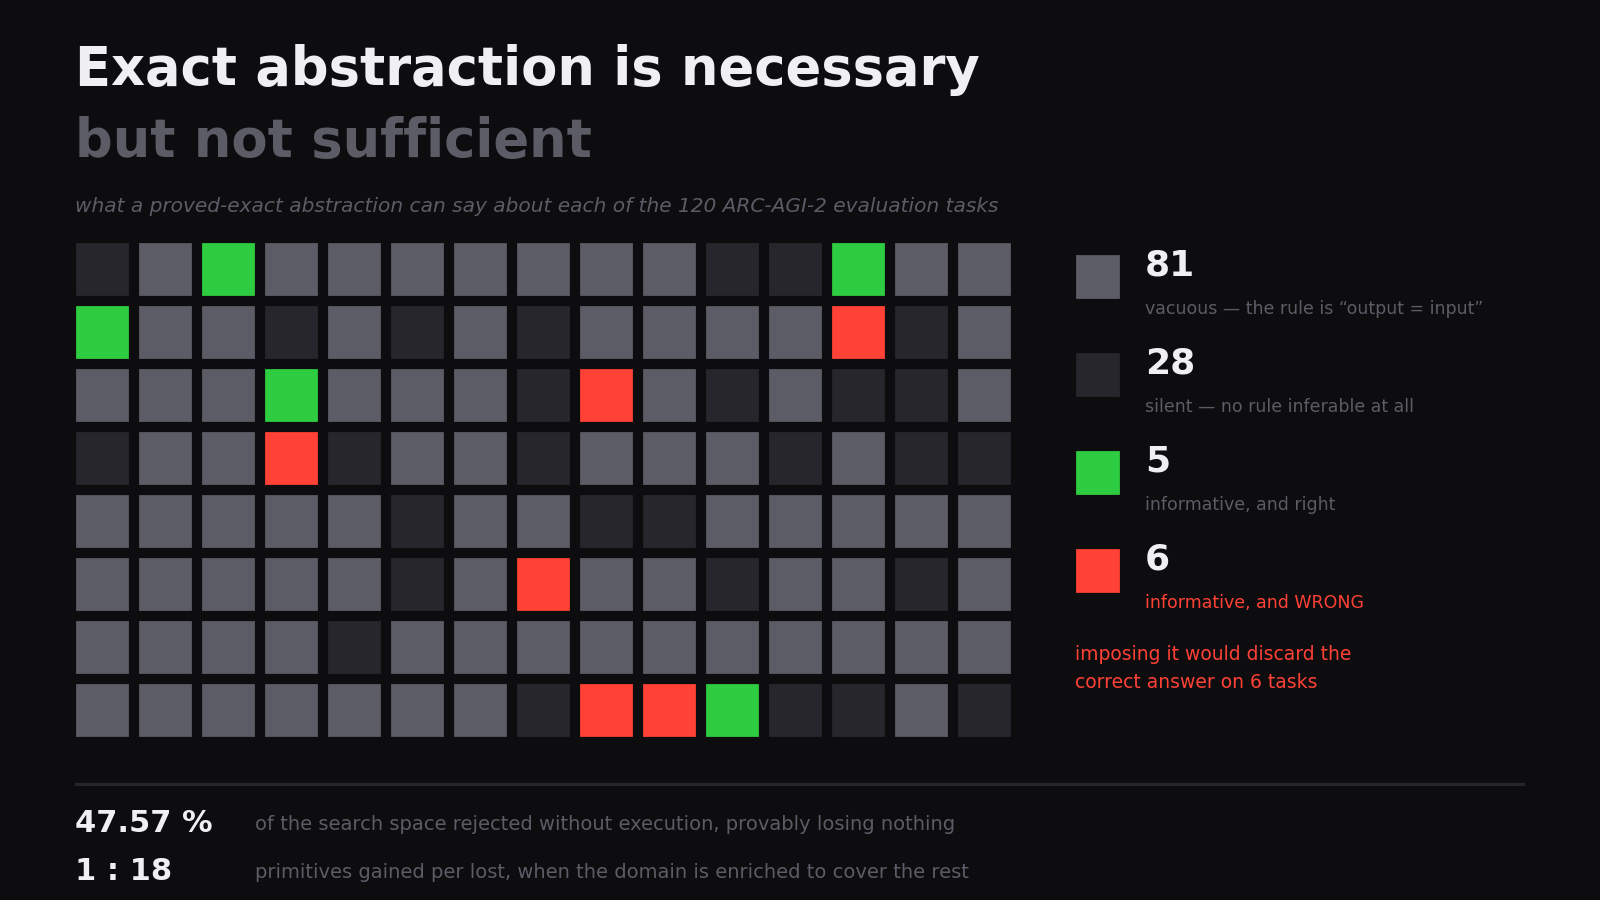

In [12]:
from IPython.display import Image, display
if os.path.exists("couverture.png"):
    display(Image("couverture.png"))
else:
    print("[couverture.png indisponible]")

## Licences

- `arc-dsl` — Michael Hodel, **MIT**, vendored unmodified with its licence file.
- ARC-AGI-2 task data — read from the competition input, under the competition's terms.
- Everything else in the attachment is ours and is released for open-sourcing, as the competition
  rules require of a winner.